# Генерация синтетических данных с использованием Faker

In [1]:
!pip install faker


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

In [3]:
# Инициализация генератора (русская локаль для реалистичных ФИО, адресов и т.д.)
fake = Faker('ru_RU')
Faker.seed(42)      # фиксируем seed для воспроизводимости
random.seed(42)

## Генерация синтетических данных для варианта "Сотрудники компании"

In [4]:
# DataFrame с отделами
def generate_departments(n):
   
    departments = []
    for i in range(1, n + 1):
        departments.append({
            'department_id': i,
            'name': fake.unique.job() + ' отдел',  # уникальное название
            'location': fake.city()
        })
    return pd.DataFrame(departments)

# DataFrame с должностями и диапазоном зарплат
def generate_positions(n: int) -> pd.DataFrame:
    
    positions = []
    for i in range(1, n + 1):
        min_salary = random.randint(30000, 60000)
        max_salary = min_salary + random.randint(20000, 80000)
        positions.append({
            'position_id': i,
            'name': fake.unique.job(),
            'min_salary': min_salary,
            'max_salary': max_salary
        })
    return pd.DataFrame(positions)

# генерируем сотрудников со случайными атрибутами
def generate_employees(n: int, department_ids: list, position_ids: list) -> pd.DataFrame:
    
    employees = []
    for emp_id in range(1, n + 1):        
        first_name = fake.first_name()
        last_name = fake.last_name()
        patronymic = fake.middle_name()
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=70)
        phone = fake.phone_number()
        email = fake.email()
        address = fake.address().replace('\n', ', ')
        
        # дата найма: не раньше 18-летия и не позже сегодняшнего дня
        min_hire_date = birth_date + timedelta(days=18*365)
        hire_date = fake.date_between(start_date=min_hire_date, end_date='today')
        
        # статус -  active / terminated (10% уволены)
        status = random.choices(['active', 'terminated'], weights=[0.9, 0.1])[0]
        
        # выбор отдела и должности
        department_id = random.choice(department_ids)
        position_id = random.choice(position_ids)
        
        # зарплата     
        salary = random.randint(40000, 150000)
        
        employees.append({
            'employee_id': emp_id,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'birth_date': birth_date,
            'gender': random.choice(['М', 'Ж']),
            'address': address,
            'phone': phone,
            'email': email,
            'hire_date': hire_date,
            'status': status,
            'department_id': department_id,
            'position_id': position_id,
            'salary': salary
        })
    return pd.DataFrame(employees)

# создать историю зарплат на основе данных сотрудников
def generate_salary_history(employees_df: pd.DataFrame, avg_records: int = 3):    
    history = []
    record_id = 1
    
    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']
        hire_date = emp['hire_date']
        current_salary = emp['salary']
        
        # количество изменений (0 – если сотрудник только нанят и ещё не было изменений)
        num_changes = random.choices([0, 1, 2, 3, 4], weights=[0.2, 0.3, 0.3, 0.1, 0.1])[0]
        
        # генерируем даты изменений (после hire_date и до сегодня)
        change_dates = sorted([fake.date_between(start_date=hire_date, end_date='today') 
                               for _ in range(num_changes)])
        
        # начальная зарплата при найме (можно сделать немного отличающейся от текущей)
        #  будем считать, что первая запись – это зарплата при найме,
        # а последующие – повышения.
        if num_changes == 0:
            # Если изменений не было, всё равно добавим одну запись (начальная)
            history.append({
                'history_id': record_id,
                'employee_id': emp_id,
                'change_date': hire_date,
                'new_salary': current_salary
            })
            record_id += 1
        else:
            # генерируем возрастающие зарплаты
            salary_values = sorted([random.randint(30000, current_salary) for _ in range(num_changes)])
            # добавляем текущую зарплату как последнюю
            salary_values.append(current_salary)
            # даты: hire_date и change_dates
            all_dates = [hire_date] + change_dates
            for i in range(len(all_dates)):
                history.append({
                    'history_id': record_id,
                    'employee_id': emp_id,
                    'change_date': all_dates[i],
                    'new_salary': salary_values[i]
                })
                record_id += 1
    return pd.DataFrame(history)

In [5]:
N_DEPARTMENTS = 10
N_POSITIONS = 20
N_EMPLOYEES = 500

In [6]:
departments_df = generate_departments(N_DEPARTMENTS)
positions_df = generate_positions(N_POSITIONS)
employees_df = generate_employees(
    N_EMPLOYEES,
    departments_df['department_id'].tolist(),
    positions_df['position_id'].tolist()
)

In [7]:
departments_df

,department_id,name,location
0,1,Диетолог отдел,клх Кырен
1,2,Метеоролог отдел,п. Волоколамск
2,3,Гепатолог отдел,г. Артем
3,4,Гомеопат отдел,п. Териберка
4,5,Бактериолог отдел,клх Усинск
5,6,Танцор отдел,с. Чикола
6,7,Нотариус отдел,ст. Ессентуки
7,8,Тележурналист отдел,к. Ельня
8,9,Литейщик отдел,г. Видное
9,10,Сиделка отдел,к. Нефедова


In [8]:
positions_df

,position_id,name,min_salary,max_salary
0,1,Мясник,50952,78248
1,2,Борт-радист,30819,99417
2,3,Философ,39012,75061
3,4,Доярка,37314,66458
4,5,Семейный врач,54132,80849
5,6,Врач скорой помощи,52174,120714
6,7,Ортопед,59234,114975
7,8,Реставратор,32848,91546
8,9,Композитор,43825,65907
9,10,Военный прокурор,30976,57116


In [9]:
employees_df

,employee_id,last_name,first_name,patronymic,birth_date,gender,address,phone,email,hire_date,status,department_id,position_id,salary
0,1,Гаврилов,Мина,Кузьминична,1973-08-09,М,"к. Бологое, пер. Островского, д. 77, 242388",+7 928 327 64 83,tatjana_03@example.org,2009-06-21,active,7,11,76421
1,2,Григорьева,Ольга,Федотович,1995-02-23,Ж,"д. Красногорск (Моск.), ш. Заречное, д. 684 ст...",8 532 871 01 22,erjabova@example.com,2023-10-09,active,6,4,52156
2,3,Крюкова,Лаврентий,Егоровна,1989-12-26,М,"п. Хасавюрт, ул. Вахитова, д. 382, 824896",83252880957,makarovamaja@example.com,2015-03-07,active,6,20,74671
3,4,Лукина,Тимур,Николаевна,2002-05-20,М,"г. Яхрома, алл. Профсоюзная, д. 951, 473829",+7 (465) 787-1331,adrian_98@example.org,2025-04-09,active,9,4,89615
4,5,Мартынов,Савватий,Станиславовна,1987-08-16,М,"п. Уварово, алл. Челюскинцев, д. 84 к. 81, 080132",8 311 656 67 01,maslovalukija@example.org,2019-06-09,active,10,12,115674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Кузнецова,Твердислав,Теймуразович,1992-04-26,Ж,"с. Кажим, бул. Ручейный, д. 1 стр. 1, 669579",+7 (996) 872-25-89,semendementev@example.org,2010-12-16,active,4,16,112173
496,497,Фомина,Амвросий,Валерьевич,1966-11-12,М,"клх Котельнич, алл. Угольная, д. 4/4 стр. 356,...",+78255442867,ikarpov@example.com,1996-12-15,active,8,16,100401
497,498,Гуляев,Мефодий,Владленович,1994-08-06,Ж,"к. Ардон, пр. Механический, д. 9/6 стр. 895, 4...",+7 (693) 358-95-13,vatslav_2008@example.net,2014-08-16,active,6,6,58344
498,499,Корнилова,Евдокия,Якубович,1994-09-13,М,"п. Партизанск, ул. 40 лет Победы, д. 8 к. 455,...",+7 179 720 38 59,karpevseev@example.org,2020-10-12,active,9,2,108674


In [10]:
# Генерация истории зарплат
salary_history_df = generate_salary_history(employees_df, avg_records=3)
salary_history_df

,history_id,employee_id,change_date,new_salary
0,1,1,2009-06-21,71333
1,2,1,2024-01-15,76421
2,3,2,2023-10-09,34948
3,4,2,2025-04-02,52156
4,5,3,2015-03-07,74671
...,...,...,...,...
1291,1292,498,2022-10-14,57426
1292,1293,498,2024-05-03,58344
1293,1294,499,2020-10-12,89827
1294,1295,499,2022-11-22,108674


In [11]:
# Сохранение в CSV
departments_df.to_csv('departments.csv', index=False)
positions_df.to_csv('positions.csv', index=False)
employees_df.to_csv('employees.csv', index=False)
salary_history_df.to_csv('salary_history.csv', index=False)

# Задание на самостоятельную работу
Создать синтетический набор данных, сохранить его в csv файлы, построить на основе данных онтологию, вывести онтограф.


### Вариант 1. Аренда электромобилей
Сущности: 
- Автомобиль: id, марка, модель, год выпуска, госномер, запас хода (км), статус (доступен, арендован, на обслуживании), тариф (цена за минуту), локация (парковка). История зарядок (JSON-массив объектов: {id станции, дата_начала, дата_конца, объём_кВт·ч, стоимость}).
- Клиент: id, ФИО, водительское удостоверение (серия, номер), телефон, email, дата регистрации.
- Аренда:id, id клиента, id автомобиля, дата и время начала, дата и время окончания, начальный пробег, конечный пробег, стоимость, статус (активна, завершена, отменена), Информация об оплате (поля внутри таблицы): сумма, способ оплаты, дата оплаты, статус оплаты.
- Зарядная станция: id, адрес, тип разъёма, количество мест, статус (работает/не работает).

Объём данных: автомобили - 100, клиенты - 500, аренды - 3000, зарядные станции -  20

Онтология:
- Классы: Автомобиль, Клиент, Аренда, ЗаряднаяСтанция.
- Связи:  клиент арендует автомобиль, автомобиль участвует в арендах, история зарядок хранится в JSON внутри автомобиля, ссылаясь на станции, Аренда содержит данные об оплате.

### Вариант 2. Банковские клиенты и транзакции
Сущности: 
- Клиент: id, ФИО, дата рождения, паспортные данные (серия, номер, кем выдан), адрес, телефон, email.
- Счёт: id, номер счёта, тип (дебетовый/кредитный), валюта, дата открытия, остаток, id клиента.
- Транзакция: id, дата, сумма, тип (пополнение/списание), id счёта, описание.
- Кредит: id, id клиента, сумма, процентная ставка, срок, дата выдачи, ежемесячный платёж.

Объём: 1000 клиентов, у каждого 1–3 счёта, на каждом 10–50 транзакций, 20% клиентов имеют кредиты.

Онтология:
- Классы: Клиент, Счёт, Транзакция, Кредит.
- Связи: клиент владеет счетами, по счетам проходят транзакции, клиент может иметь кредиты.

### Вариант 3. Медицинские пациенты и приёмы
Сущности:
- Пациент: id, ФИО, дата рождения, пол, полис ОМС, СНИЛС, адрес, телефон.
- Врач: id, ФИО, специальность, кабинет.
- Приём: id, дата и время, id пациента, id врача, диагноз (код МКБ-10), жалобы, назначения (JSON-массив объектов: {лекарство, дозировка, курс}).
- Больничный лист: id, id приёма, дата начала, дата окончания, диагноз.

Объём: 2000 пациентов, 50 врачей, 5–10 приёмов на пациента за последние 2 года, часть с больничными.

Онтология:
- Классы: Пациент, Врач, Приём, БольничныйЛист.
- Связи: пациент посещает врача (приём), по приёму может быть открыт больничный, назначения хранятся в JSON приёма (Атрибут класса Прием).

### Вариант 4. Студенты и успеваемость
Сущности:
- Студент: id, ФИО, дата рождения, группа, год поступления, форма обучения.
- Группа: id, номер, курс, институт, направление подготовки.
- Предмет: id, название, семестр, количество часов, форма контроля (экзамен/зачёт), id преподавателя.
- Оценка: id, id студента, id предмета, дата, оценка (число или зачёт/незачёт).
- Преподаватель: id, ФИО, кафедра.

Объём: 10 групп по 25 студентов = 250 студентов, 30 предметов, у каждого студента оценки по всем предметам (≈ 7500 записей).

Онтология
- Классы: Студент, Группа, Предмет, Оценка, Преподаватель.
- Связи: студент учится в группе, группа изучает предметы (связка группа-предмет), преподаватель ведёт предмет, студент получает оценки.

### Вариант 5. Интернет-магазин: товары, заказы, покупатели
Сущности:
- Покупатель: id, email, ФИО, телефон, дата регистрации.
- Товар: id, название, категория, цена, остаток на складе.
- Заказ: id, id покупателя, дата, статус (новый, оплачен, отгружен, доставлен).
- Состав заказа: id заказа, id товара, количество, цена в момент заказа.
- Отзыв: id, id покупателя, id товара, оценка (1–5), текст, дата.

Объём: 500 покупателей, 1000 товаров, 3000 заказов (в среднем по 2 товара в заказе), 1500 отзывов.

Онтология:
- Классы: Покупатель, Товар, Заказ, СтрокаЗаказа, Отзыв.
- Связи: покупатель делает заказ, заказ содержит товары (с количеством), покупатель оставляет отзыв на товар.

### Вариант 6. Недвижимость и сделки
Сущности: 
- Объект недвижимости: id, адрес, тип (квартира/дом/коммерческое), площадь, количество комнат, этаж, год постройки, кадастровый номер.
- Владелец: id, ФИО, паспортные данные, доля (если долевая собственность).
- Сделка купли-продажи: id, дата, id объекта, id продавца, id покупателя, цена, нотариус.
- Ценовой архив: id объекта, дата изменения, новая цена (для отслеживания динамики).

Объём: 2000 объектов, 300 владельцев, 150 сделок, у каждого объекта 2–3 записи цен.

Онтология:
- Классы: Объект, Владелец, Сделка, ЦеновойАрхив.
- Связи: объект может иметь нескольких владельцев (доли), сделка связывает продавца, покупателя и объект.

### Вариант 7. Транспортные средства и штрафы
Сущности:
- Владелец ТС: id, ФИО, водительское удостоверение (серия, номер), адрес, телефон.
- Автомобиль: id, госномер, марка, модель, год выпуска, VIN, цвет, id владельца.
- Штраф: id, id автомобиля, дата, статья нарушения, сумма, статус (оплачен/не оплачен).
- Страховой полис: id, id автомобиля, компания, дата начала, дата окончания, стоимость.

Объём: 1000 владельцев, 1200 автомобилей (некоторые владеют несколькими), 5000 штрафов, 1500 полисов.

Онтология:
- Классы: Владелец, Автомобиль, Штраф, Полис.
- Связи: владелец владеет автомобилями, автомобиль имеет штрафы и страховки.

### Вариант 8. Библиотека: книги, читатели, выдачи
Сущности:
- Книга: id, ISBN, название, автор, год издания, издательство, жанр, количество экземпляров в библиотеке.
- Читатель: id, ФИО, дата рождения, адрес, телефон, email, дата регистрации.
- Выдача: id, id книги, id читателя, дата выдачи, дата возврата (если есть), фактическая дата возврата.
- Бронь: id, id книги, id читателя, дата брони, статус (активна/исполнена).

Объём: 500 книг, 300 читателей, 2000 выдач, 100 броней.

Онтология:
- Классы: Книга, Читатель, Выдача, Бронь.
- Связи: читатель берёт книгу (выдача), может бронировать.

### Вариант 9. Техподдержка: заявки и обращения
Сущности:
- Пользователь: id, ФИО, email, телефон, уровень (обычный/премиум).
- Категория заявки: id, название, описание.
- Сотрудник поддержки: id, ФИО, отдел, количество решённых заявок.
- Заявка: id, id пользователя, id категории, тема, описание, дата создания, статус (новая, в работе, решена, закрыта), приоритет, id сотрудника (назначен), комментарии (JSON-массив объектов: {id автора (пользователь или сотрудник), текст, дата}).

Объём данных: пользователи - 1000, категории - 5, сотрудники - 10, заявки - 5000, комментарии - 15 000  (общее на все заявки)

Онтология:
- Классы: Пользователь, Категория, Сотрудник, Заявка.
- Связи: пользователь создаёт заявку; заявка относится к категории; заявка назначается сотруднику; комментарии принадлежат заявке (в JSON).

### Вариант 10. Доставка обедов из ресторанов
Сущности: 
- Ресторан: id, название, адрес, кухня (тип кухни), рейтинг.
- Блюдо: id, название, id ресторана, категория, цена, вес/порция, калории.
- Клиент: id, ФИО, телефон, email, адрес доставки (основной), дата регистрации.
- Заказ: id, id клиента, id ресторана, дата и время заказа, статус (принят, готовится, доставлен, отменён), общая сумма, способ оплаты, состав заказа (JSON-массив объектов: {id блюда, количество, цена_в_момент_заказа}), информация о доставке (поля внутри той же таблицы): курьер (ФИО), дата и время назначения курьера, дата и время фактической доставки, статус доставки (назначен, в пути, выполнен), фактический адрес доставки (если отличается от адреса клиента)

Объём данных: рестораны -  20, блюда - в среднем 20 на ресторан, клиенты -  1000, заказы - 5000.

Онтология: 
- Классы: Ресторан, Блюдо, Клиент, Заказ.
- Связи: ресторан предлагает блюда, клиент оформляет заказ, заказ ссылается на ресторан и клиента.

Состав заказа и данные доставки хранятся внутри сущности «Заказ» (денормализовано с использованием JSON).


In [12]:
!pip install pandas
!pip install faker
!pip install owlready2 networkx matplotlib
!pip install networkx


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import random
import json
from faker import Faker
from datetime import datetime, timedelta

# Инициализация
fake = Faker('ru_RU')
Faker.seed(42)
random.seed(42)

# Константы
N_RESTAURANTS = 20
N_DISHES_PER_RESTAURANT = 20  # в среднем
N_CLIENTS = 1000
N_ORDERS = 5000

In [14]:
# 1. Рестораны
def generate_restaurants(n):
    restaurants = []
    cuisines = ['Русская', 'Итальянская', 'Японская', 'Китайская', 'Грузинская', 
                'Французская', 'Американская', 'Мексиканская', 'Тайская', 'Узбекская']
    for i in range(1, n + 1):
        restaurants.append({
            'restaurant_id': i,
            'name': fake.company() + ' (' + random.choice(cuisines) + ')',
            'address': fake.address().replace('\n', ', '),
            'cuisine': random.choice(cuisines),
            'rating': round(random.uniform(3.0, 5.0), 1)
        })
    return pd.DataFrame(restaurants)

# 2. Блюда
def generate_dishes(restaurants_df):
    dishes = []
    dish_id = 1
    categories = ['Салат', 'Супы', 'Горячее', 'Гарнир', 'Десерт', 'Напитки', 'Закуски']
    
    for _, restaurant in restaurants_df.iterrows():
        n_dishes = random.randint(15, 25)
        for _ in range(n_dishes):
            dishes.append({
                'dish_id': dish_id,
                'name': fake.word().capitalize() + ' ' + fake.word().capitalize(),
                'restaurant_id': restaurant['restaurant_id'],
                'category': random.choice(categories),
                'price': round(random.randint(150, 1500) / 10, 1),
                'weight_portion': random.choice(['200g', '250g', '300g', '350g', '400g', '500g', '1kg']),
                'calories': random.randint(150, 1200)
            })
            dish_id += 1
    return pd.DataFrame(dishes)

# 3. Клиенты
def generate_clients(n):
    clients = []
    for i in range(1, n + 1):
        first_name = fake.first_name()
        last_name = fake.last_name()
        patronymic = fake.middle_name()
        clients.append({
            'client_id': i,
            'full_name': f"{last_name} {first_name} {patronymic}",
            'phone': fake.phone_number(),
            'email': fake.email(),
            'main_address': fake.address().replace('\n', ', '),
            'registration_date': fake.date_between(start_date='-3y', end_date='today')
        })
    return pd.DataFrame(clients)

# 4. Заказы
def generate_orders(n_orders, clients_df, restaurants_df, dishes_df):
    orders = []
    statuses = ['принят', 'готовится', 'доставлен', 'отменён']
    delivery_statuses = ['назначен', 'в пути', 'выполнен']
    payment_methods = ['Карта', 'Наличные', 'ApplePay', 'GooglePay', 'СБП']
    
    for order_id in range(1, n_orders + 1):
        client = clients_df.sample(1).iloc[0]
        restaurant = restaurants_df.sample(1).iloc[0]
        
        # Состав заказа (2-5 блюд)
        restaurant_dishes = dishes_df[dishes_df['restaurant_id'] == restaurant['restaurant_id']]
        if len(restaurant_dishes) == 0:
            continue
            
        n_items = random.randint(1, 5)
        order_items = []
        total_sum = 0
        
        for _ in range(n_items):
            dish = restaurant_dishes.sample(1).iloc[0]
            quantity = random.randint(1, 3)
            price_at_order = dish['price']
            order_items.append({
                'dish_id': int(dish['dish_id']),
                'quantity': quantity,
                'price_at_order': price_at_order
            })
            total_sum += price_at_order * quantity
        
        # Время заказа (за последние 6 месяцев)
        order_datetime = fake.date_time_between(start_date='-6M', end_date='now')
        
        # Статус заказа (вероятность отмены 5%)
        status = random.choices(statuses, weights=[0.2, 0.2, 0.55, 0.05])[0]
        
        # Информация о доставке
        courier_name = f"{fake.last_name()} {fake.first_name()}"
        assigned_time = order_datetime + timedelta(minutes=random.randint(2, 10))
        
        actual_delivery_time = None
        delivery_status = random.choice(delivery_statuses)
        if status == 'доставлен':
            actual_delivery_time = order_datetime + timedelta(minutes=random.randint(20, 90))
            delivery_status = 'выполнен'
        elif status == 'отменён':
            delivery_status = None
        
        actual_address = None
        if random.random() < 0.15:  # 15% заказов на другой адрес
            actual_address = fake.address().replace('\n', ', ')
        
        orders.append({
            'order_id': order_id,
            'client_id': client['client_id'],
            'restaurant_id': restaurant['restaurant_id'],
            'order_datetime': order_datetime,
            'status': status,
            'total_amount': round(total_sum, 2),
            'payment_method': random.choice(payment_methods),
            'order_items': json.dumps(order_items, ensure_ascii=False),
            'courier_name': courier_name if status != 'отменён' else None,
            'delivery_assigned_time': assigned_time if status != 'отменён' else None,
            'delivery_actual_time': actual_delivery_time,
            'delivery_status': delivery_status,
            'actual_delivery_address': actual_address
        })
    
    return pd.DataFrame(orders)

In [15]:
# Генерация
restaurants_df = generate_restaurants(N_RESTAURANTS)
dishes_df = generate_dishes(restaurants_df)
clients_df = generate_clients(N_CLIENTS)
orders_df = generate_orders(N_ORDERS, clients_df, restaurants_df, dishes_df)

In [16]:
# Сохранение в CSV (как в вашем коде)
restaurants_df.to_csv('restaurants.csv', index=False)
dishes_df.to_csv('dishes.csv', index=False)
clients_df.to_csv('clients.csv', index=False)
orders_df.to_csv('orders.csv', index=False)

In [17]:
# Просмотр результатов
print("=== Рестораны ===")
print(restaurants_df.head())
print(f"\nВсего ресторанов: {len(restaurants_df)}")

print("\n=== Блюда ===")
print(dishes_df.head())
print(f"\nВсего блюд: {len(dishes_df)}")

print("\n=== Клиенты ===")
print(clients_df.head())
print(f"\nВсего клиентов: {len(clients_df)}")

print("\n=== Заказы ===")
print(orders_df.head())
print(f"\nВсего заказов: {len(orders_df)}")

=== Рестораны ===
   restaurant_id                                  name  \
0              1            Мосинжпроект (Итальянская)   
1              2         Афанасьев Лимитед (Китайская)   
2              3  ЗАО «Лобанов-Кабанова» (Итальянская)   
3              4    ИП «Рогов Гаврилов» (Американская)   
4              5    РАО «Родионов-Якушева» (Китайская)   

                                             address    cuisine  rating  
0        п. Кизилюрт, бул. Кузнечный, д. 196, 133890    Русская     4.5  
1           с. Чикола, ш. Лесное, д. 66 к. 3, 511615  Китайская     3.3  
2  д. Гремячинск (Бурят.), ул. Кирова, д. 4 к. 50...    Тайская     3.2  
3  д. Златоуст, бул. Владимирский, д. 77 стр. 9, ...    Русская     3.1  
4       клх Тамбов, бул. Гафури, д. 34 к. 98, 969653  Китайская     4.0  

Всего ресторанов: 20

=== Блюда ===
   dish_id                    name  restaurant_id category  price  \
0        1          Эпоха Засунуть              1  Напитки   69.6   
1        2    

In [18]:
from owlready2 import *
import networkx as nx
import matplotlib.pyplot as plt

# Создание онтологии
onto = get_ontology("http://example.org/food_delivery_ontology.owl")

# Определение классов
with onto:
    class Restaurant(Thing):
        pass
    
    class Dish(Thing):
        pass
    
    class Client(Thing):
        pass
    
    class Order(Thing):
        pass

# Определение свойств (связей)
with onto:
    # Объектные свойства
    class offers(Dish >> Restaurant):  # Ресторан предлагает блюдо
        pass
    
    class places(Order >> Client):  # Клиент оформляет заказ
        pass
    
    class from_restaurant(Order >> Restaurant):  # Заказ из ресторана
        pass
    
    class contains(Dish >> Order):  # Заказ содержит блюдо
        pass
    
    # Инверсные свойства
    class offered_by(Restaurant >> Dish):
        inverse = offers
    
    class ordered_by(Client >> Order):
        inverse = places
    
    class restaurant_of(Order >> Restaurant):
        inverse = from_restaurant
    
    class in_order(Order >> Dish):
        inverse = contains

# Атрибуты классов (дата свойства)
with onto:
    class has_rating(Restaurant >> float):
        pass
    
    class has_cuisine(Restaurant >> str):
        pass
    
    class has_price(Dish >> float):
        pass
    
    class has_category(Dish >> str):
        pass
    
    class has_phone(Client >> str):
        pass
    
    class has_email(Client >> str):
        pass
    
    class has_status(Order >> str):
        pass
    
    class has_total_amount(Order >> float):
        pass
    
    class has_payment_method(Order >> str):
        pass
    
    class has_courier(Order >> str):
        pass
    
    class has_delivery_status(Order >> str):
        pass

print("Онтология создана")

Онтология создана


C:\Users\zhora\AppData\Local\Temp\ipykernel_15548\422622654.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


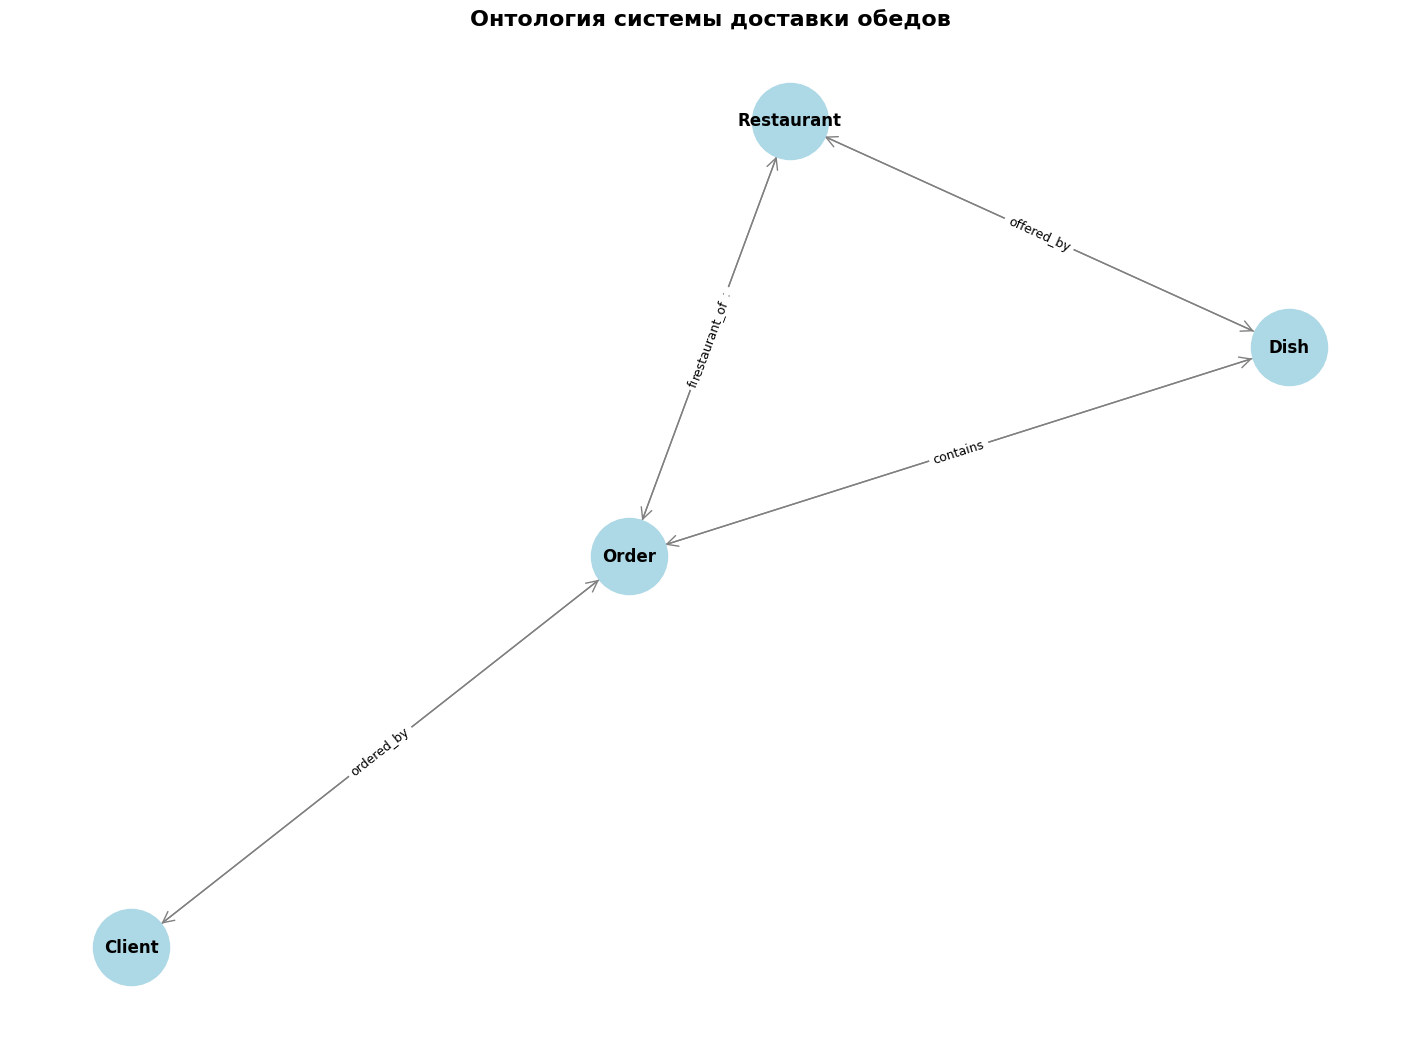

In [19]:
# Создание графа для визуализации
G = nx.DiGraph()

# Добавление узлов-классов
classes = ['Restaurant', 'Dish', 'Client', 'Order']
for cls in classes:
    G.add_node(cls, type='class')

# Добавление связей (отношений)
relations = [
    ('Restaurant', 'offers', 'Dish'),
    ('Dish', 'offered_by', 'Restaurant'),
    ('Client', 'places', 'Order'),
    ('Order', 'ordered_by', 'Client'),
    ('Restaurant', 'from_restaurant', 'Order'),
    ('Order', 'restaurant_of', 'Restaurant'),
    ('Order', 'contains', 'Dish'),
    ('Dish', 'in_order', 'Order')
]

for src, rel, dst in relations:
    G.add_edge(src, dst, label=rel)

# Визуализация
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=3000, font_size=12, font_weight='bold',
        edge_color='gray', arrows=True, arrowstyle='->', 
        arrowsize=20)

# Добавление подписей к рёбрам
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Онтология системы доставки обедов", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

C:\Users\zhora\AppData\Local\Temp\ipykernel_15548\2336039372.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


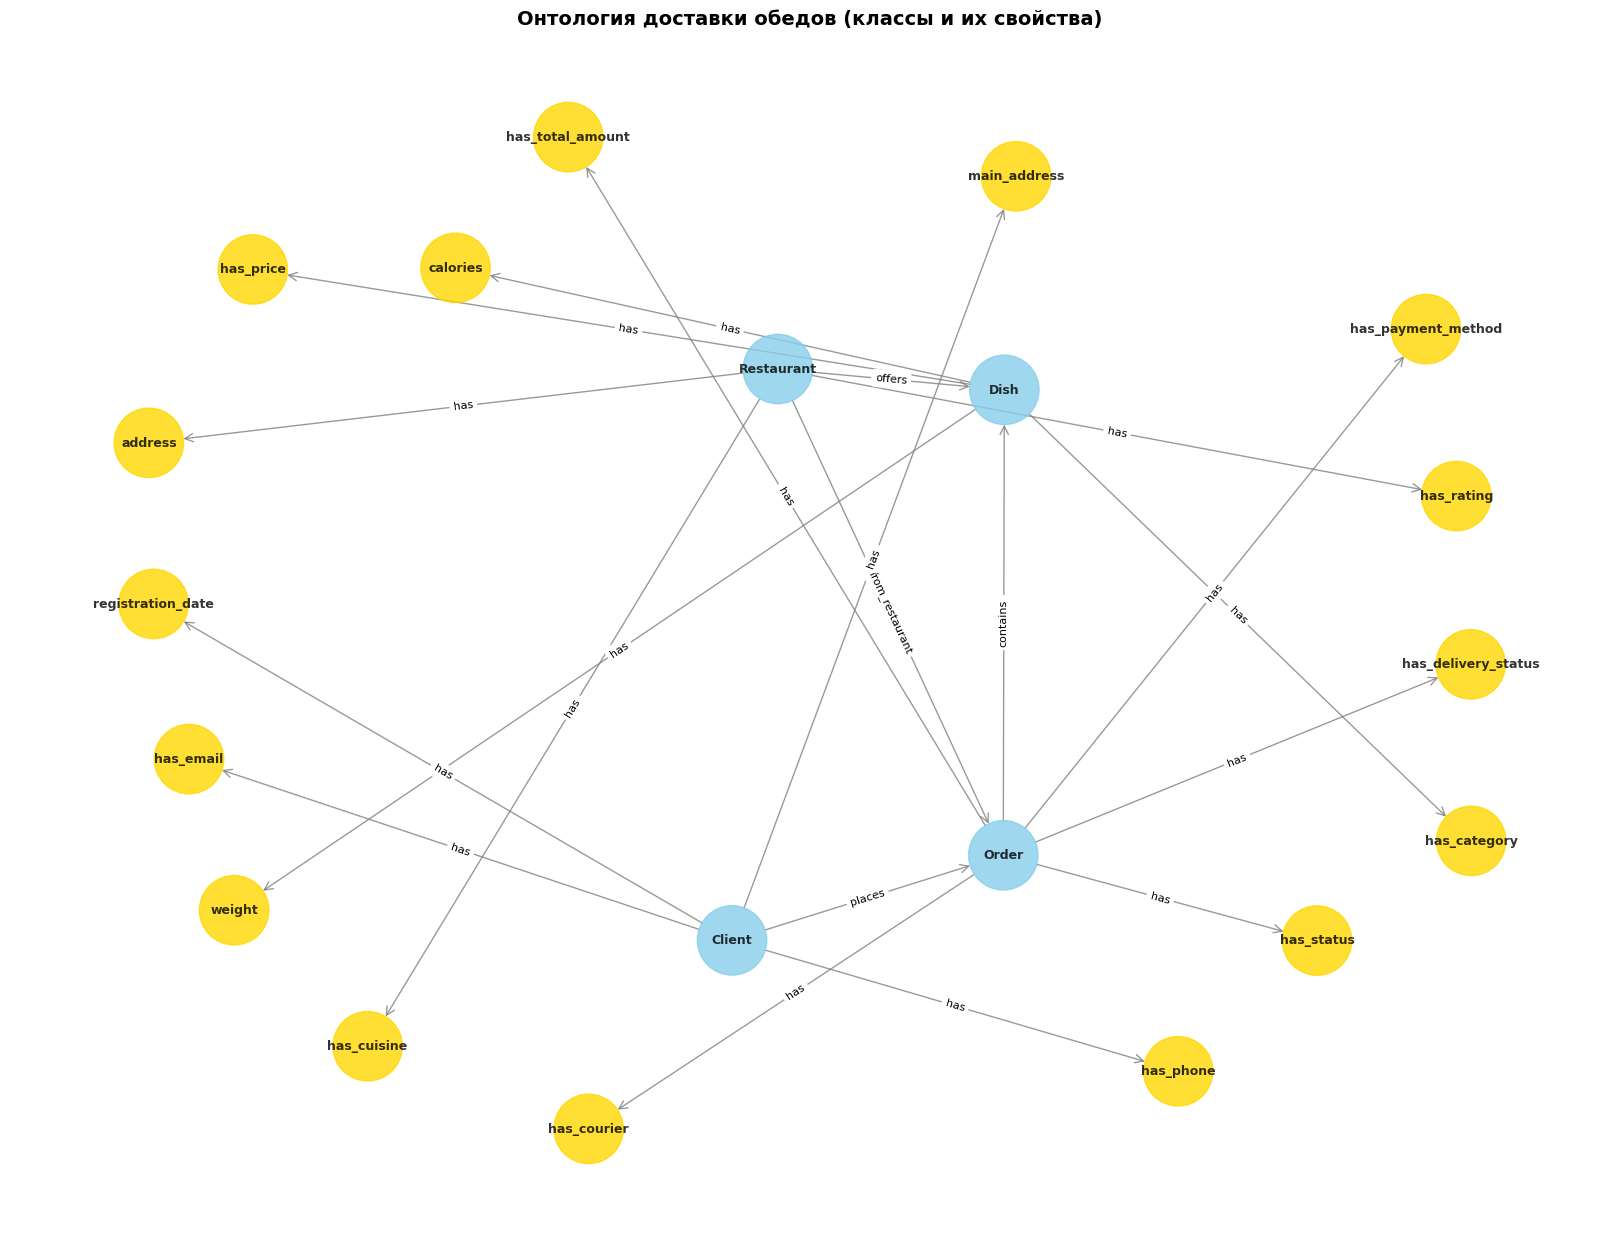

In [20]:
# Детальная визуализация со свойствами
plt.figure(figsize=(16, 12))

# Создание многоуровневого графа
G2 = nx.DiGraph()

# Классы и их атрибуты
class_attributes = {
    'Restaurant': ['has_rating', 'has_cuisine', 'address'],
    'Dish': ['has_price', 'has_category', 'weight', 'calories'],
    'Client': ['has_phone', 'has_email', 'main_address', 'registration_date'],
    'Order': ['has_status', 'has_total_amount', 'has_payment_method', 
              'has_courier', 'has_delivery_status']
}

# Добавление узлов
for cls, attrs in class_attributes.items():
    G2.add_node(cls, type='class', level=0)
    for attr in attrs:
        G2.add_node(attr, type='attribute', level=1)
        G2.add_edge(cls, attr, label='has')

# Добавление связей между классами
class_relations = [
    ('Restaurant', 'offers', 'Dish'),
    ('Client', 'places', 'Order'),
    ('Restaurant', 'from_restaurant', 'Order'),
    ('Order', 'contains', 'Dish')
]

for src, rel, dst in class_relations:
    G2.add_edge(src, dst, label=rel, type='relation')

# Визуализация с разными цветами
pos2 = nx.spring_layout(G2, k=2, seed=42)

# Разные цвета для классов и атрибутов
node_colors = ['#87CEEB' if G2.nodes[n]['type'] == 'class' else '#FFD700' for n in G2.nodes]

nx.draw(G2, pos2, with_labels=True, node_color=node_colors,
        node_size=2500, font_size=9, font_weight='bold',
        edge_color='gray', arrows=True, arrowstyle='->', 
        arrowsize=15, alpha=0.8)

# Подписи рёбер
edge_labels2 = {(u, v): d['label'] for u, v, d in G2.edges(data=True)}
nx.draw_networkx_edge_labels(G2, pos2, edge_labels=edge_labels2, font_size=8)

plt.title("Онтология доставки обедов (классы и их свойства)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# Статистика и проверка данных
print("=" * 50)
print("Статистика сгенерированных данных:")
print("=" * 50)

print(f"\n Рестораны: {len(restaurants_df)}")
print(f"   - Средний рейтинг: {restaurants_df['rating'].mean():.2f}")
print(f"   - Кухни: {restaurants_df['cuisine'].unique()}")

print(f"\n Блюда: {len(dishes_df)}")
print(f"   - Средняя цена: {dishes_df['price'].mean():.2f} ₽")
print(f"   - Категории: {dishes_df['category'].unique()}")

print(f"\n Клиенты: {len(clients_df)}")

print(f"\n Заказы: {len(orders_df)}")
print(f"   - Средняя сумма: {orders_df['total_amount'].mean():.2f} ₽")
print(f"   - Статусы заказов:\n{orders_df['status'].value_counts()}")
print(f"   - Способы оплаты:\n{orders_df['payment_method'].value_counts()}")
print(f"   - Статусы доставки:\n{orders_df['delivery_status'].value_counts()}")

Статистика сгенерированных данных:

 Рестораны: 20
   - Средний рейтинг: 3.88
   - Кухни: <StringArray>
[     'Русская',    'Китайская',      'Тайская', 'Американская',
   'Грузинская',     'Японская',  'Итальянская',  'Французская']
Length: 8, dtype: str

 Блюда: 401
   - Средняя цена: 84.58 ₽
   - Категории: <StringArray>
['Напитки', 'Десерт', 'Супы', 'Закуски', 'Салат', 'Горячее', 'Гарнир']
Length: 7, dtype: str

 Клиенты: 1000

 Заказы: 5000
   - Средняя сумма: 505.25 ₽
   - Статусы заказов:
status
доставлен    2763
принят        989
готовится     985
отменён       263
Name: count, dtype: int64
   - Способы оплаты:
payment_method
Наличные     1014
Карта        1005
GooglePay    1002
ApplePay      991
СБП           988
Name: count, dtype: int64
   - Статусы доставки:
delivery_status
выполнен    3418
в пути       681
назначен     638
Name: count, dtype: int64


In [22]:
# Примеры JSON-полей
print("\n" + "=" * 50)
print("Примеры JSON-данных (состав заказа):")
print("=" * 50)

for i in range(3):
    sample_order = orders_df.iloc[i]
    order_items = json.loads(sample_order['order_items'])
    print(f"\nЗаказ #{sample_order['order_id']}:")
    for item in order_items:
        print(f"  - Блюдо ID: {item['dish_id']}, Количество: {item['quantity']}, Цена: {item['price_at_order']} ₽")


Примеры JSON-данных (состав заказа):

Заказ #1:
  - Блюдо ID: 6, Количество: 3, Цена: 79.6 ₽

Заказ #2:
  - Блюдо ID: 162, Количество: 3, Цена: 60.9 ₽
  - Блюдо ID: 162, Количество: 3, Цена: 60.9 ₽
  - Блюдо ID: 172, Количество: 1, Цена: 76.7 ₽

Заказ #3:
  - Блюдо ID: 5, Количество: 3, Цена: 26.4 ₽
  - Блюдо ID: 7, Количество: 1, Цена: 58.2 ₽


In [23]:
import json


sample_orders = []

for i in range(4):
    sample_order = orders_df.iloc[i]
    order_items = json.loads(sample_order['order_items'])
    
    sample_orders.append({
        'order_id': int(sample_order['order_id']),
        'client_id': int(sample_order['client_id']),
        'restaurant_id': int(sample_order['restaurant_id']),
        'total_amount': float(sample_order['total_amount']),
        'items': order_items
    })


with open('sample_orders.json', 'w', encoding='utf-8') as f:
    json.dump(sample_orders, f, ensure_ascii=False, indent=2)

print("✅ Сохранено 4 заказа в файл: sample_orders.json")
print(f"\nПример первого заказа:")
print(json.dumps(sample_orders[0], ensure_ascii=False, indent=2))

✅ Сохранено 4 заказа в файл: sample_orders.json

Пример первого заказа:
{
  "order_id": 1,
  "client_id": 950,
  "restaurant_id": 1,
  "total_amount": 238.8,
  "items": [
    {
      "dish_id": 6,
      "quantity": 3,
      "price_at_order": 79.6
    }
  ]
}
